In [50]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


## About this dataset
The house-price data predicting SalePrices of Houses

## About the attributes
There were total 81 columns, so we have described only 26 columns used in the project.

- MSSubClass: Identifies the type of dwelling involved in the sale
- MSZoning: Identifies the general zoning classification of the sale.
- LotArea: Lot size in square feet
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- Neighborhood: Physical locations within Ames city limits
- OverallQual: Rates the overall material and finish of the house
- OverallCond: Rates the overall condition of the house
- YearBuilt: Original construction date
- Exterior1st: Exterior covering on house
- Foundation: Type of foundation
- BsmtQual: Evaluates the height of the basement
- BsmtCond: Evaluates the general condition of the basement
- TotalBsmtSF: Total square feet of basement area
- 1stFlrSF: First Floor square feet
- GrLivArea: Above grade (ground) living area square feet
- Functional: Home functionality (Assume typical unless deductions are warranted)
- GarageType: Garage location
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- YrSold: Year Sold (YYYY)
- SaleType: Type of sale
- SalePrice: HouseSoldPrice

In [71]:
data=pd.read_csv("HousePrices.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [72]:
data.replace({"?":np.nan,0:np.nan},inplace=True)

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [74]:
data.drop(["Id","LotFrontage","Alley","LandSlope","Condition2","BldgType","YearRemodAdd","Exterior2nd","MasVnrType","MasVnrArea","ExterCond","BsmtExposure","BsmtFinType1","BsmtFinSF1","BsmtFinType2","BsmtFinSF2","BsmtUnfSF","2ndFlrSF","LowQualFinSF","BsmtFullBath","BsmtHalfBath","HalfBath","KitchenAbvGr","BedroomAbvGr","Fireplaces","FireplaceQu","GarageYrBlt","GarageFinish","GarageCars","PavedDrive","WoodDeckSF","OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch","PoolArea","PoolQC","Fence","MiscFeature","MiscVal","MoSold","Street","Condition1","HouseStyle","RoofStyle","RoofMatl","ExterQual","Heating","HeatingQC","CentralAir","FullBath","Electrical","KitchenQual","TotRmsAbvGrd","SaleCondition"],axis=1,inplace=True)

In [75]:
missing_value_columns=data.columns[data.isnull().any()].tolist()
data[missing_value_columns]

,BsmtQual,BsmtCond,TotalBsmtSF,GarageType,GarageArea,GarageQual,GarageCond
0,Gd,TA,856.0,Attchd,548.0,TA,TA
1,Gd,TA,1262.0,Attchd,460.0,TA,TA
2,Gd,TA,920.0,Attchd,608.0,TA,TA
3,TA,Gd,756.0,Detchd,642.0,TA,TA
4,Gd,TA,1145.0,Attchd,836.0,TA,TA
...,...,...,...,...,...,...,...
1455,Gd,TA,953.0,Attchd,460.0,TA,TA
1456,Gd,TA,1542.0,Attchd,500.0,TA,TA
1457,TA,Gd,1152.0,Attchd,252.0,TA,TA
1458,TA,TA,1078.0,Attchd,240.0,TA,TA


In [76]:
missing_numeric=data[missing_value_columns].select_dtypes(include=["float64","int64"])

In [77]:
for column in missing_numeric.columns:
    mean=data[column].astype('float').mean(axis=0)
    data[column].replace(np.nan,mean,inplace=True)

In [78]:
missing_categoric=data[missing_value_columns].select_dtypes(include=["object"])

In [79]:
for column in missing_categoric.columns:
    frequency=data[column].value_counts().idxmax()
    data[column].replace(np.nan,frequency,inplace=True)

In [80]:
data.head()

,MSSubClass,MSZoning,LotArea,LotShape,LandContour,Utilities,LotConfig,Neighborhood,OverallQual,OverallCond,...,1stFlrSF,GrLivArea,Functional,GarageType,GarageArea,GarageQual,GarageCond,YrSold,SaleType,SalePrice
0,60,RL,8450,Reg,Lvl,AllPub,Inside,CollgCr,7,5,...,856,1710,Typ,Attchd,548.0,TA,TA,2008,WD,208500
1,20,RL,9600,Reg,Lvl,AllPub,FR2,Veenker,6,8,...,1262,1262,Typ,Attchd,460.0,TA,TA,2007,WD,181500
2,60,RL,11250,IR1,Lvl,AllPub,Inside,CollgCr,7,5,...,920,1786,Typ,Attchd,608.0,TA,TA,2008,WD,223500
3,70,RL,9550,IR1,Lvl,AllPub,Corner,Crawfor,7,5,...,961,1717,Typ,Detchd,642.0,TA,TA,2006,WD,140000
4,60,RL,14260,IR1,Lvl,AllPub,FR2,NoRidge,8,5,...,1145,2198,Typ,Attchd,836.0,TA,TA,2008,WD,250000


In [81]:
categoric_data=data.select_dtypes(include=["object"])
numeric_data=data.select_dtypes(include=["int64","float64"])

In [82]:
result=[]
for column in categoric_data.columns:
    group=data.groupby(column)["SalePrice"].apply(list)
    f_static, p_value=f_oneway(*group)
    result.append({"column":column,"p_value":p_value})
df=pd.DataFrame(result)
df.sort_values(by="p_value",ascending=False)

,column,p_value
3,Utilities,5.847168e-01
10,Functional,4.841697e-04
4,LotConfig,3.163167e-06
13,GarageCond,1.532279e-06
12,GarageQual,9.588016e-07
2,LandContour,2.742217e-08
9,BsmtCond,7.166578e-09
1,LotShape,6.447524e-25
0,MSZoning,8.817634e-35
14,SaleType,5.039767e-42


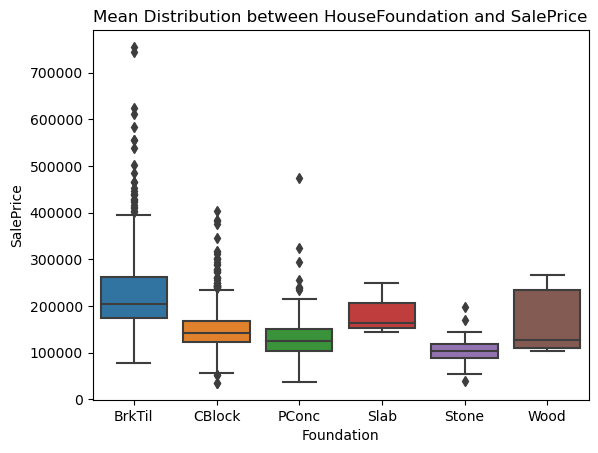

In [83]:
sns.boxplot(x="Foundation",y="SalePrice",data=data)
plt.xticks(ticks=[0,1,2,3,4,5],labels=["BrkTil","CBlock","PConc","Slab","Stone","Wood"])
plt.title("Mean Distribution between HouseFoundation and SalePrice")
plt.show()

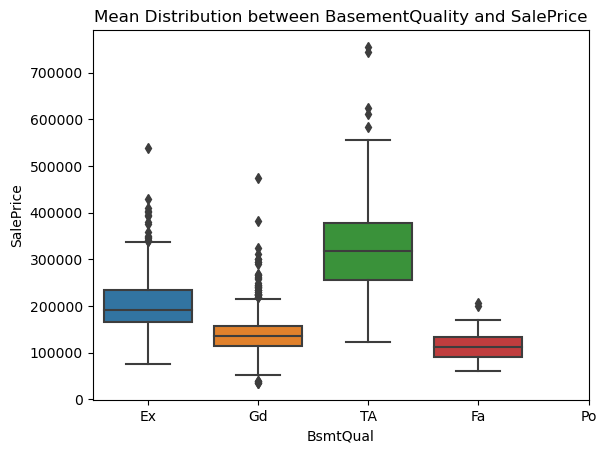

In [84]:
sns.boxplot(x="BsmtQual",y="SalePrice",data=data)
plt.xticks(ticks=[0,1,2,3,4],labels=["Ex","Gd","TA","Fa","Po"])
plt.title("Mean Distribution between BasementQuality and SalePrice")
plt.show()

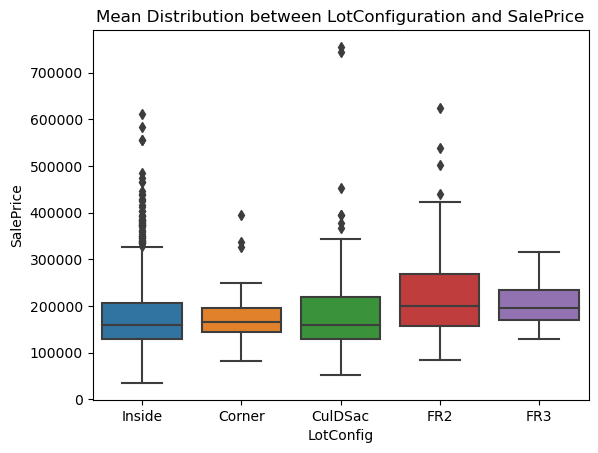

In [85]:
sns.boxplot(x="LotConfig",y="SalePrice",data=data)
plt.xticks(ticks=[0,1,2,3,4],labels=["Inside","Corner","CulDSac","FR2","FR3"])
plt.title("Mean Distribution between LotConfiguration and SalePrice")
plt.show()

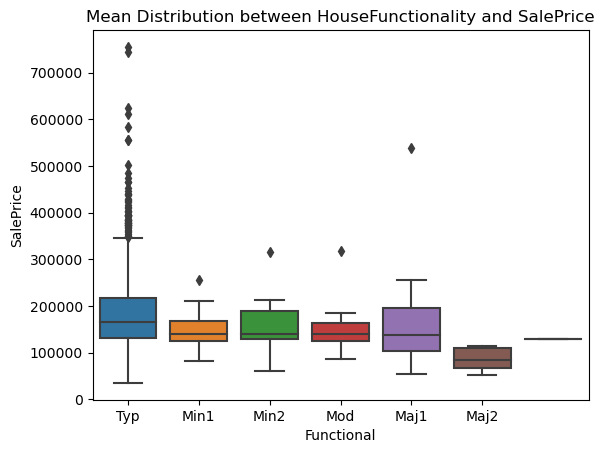

In [86]:
sns.boxplot(x="Functional",y="SalePrice",data=data)
plt.xticks(ticks=[0,1,2,3,4,5],labels=["Typ","Min1","Min2","Mod","Maj1","Maj2"])
plt.title("Mean Distribution between HouseFunctionality and SalePrice")
plt.show()

In [87]:
numeric_data.corr()["SalePrice"].drop("SalePrice").sort_values()

MSSubClass    -0.084284
OverallCond   -0.077856
YrSold        -0.028923
LotArea        0.263843
YearBuilt      0.522897
GarageArea     0.588160
TotalBsmtSF    0.601484
1stFlrSF       0.605852
GrLivArea      0.708624
OverallQual    0.790982
Name: SalePrice, dtype: float64

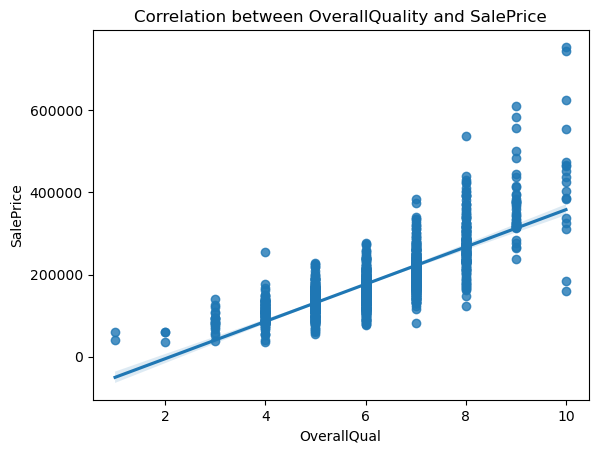

In [88]:
sns.regplot(x="OverallQual",y="SalePrice",data=data)
plt.title("Correlation between OverallQuality and SalePrice")
plt.show()

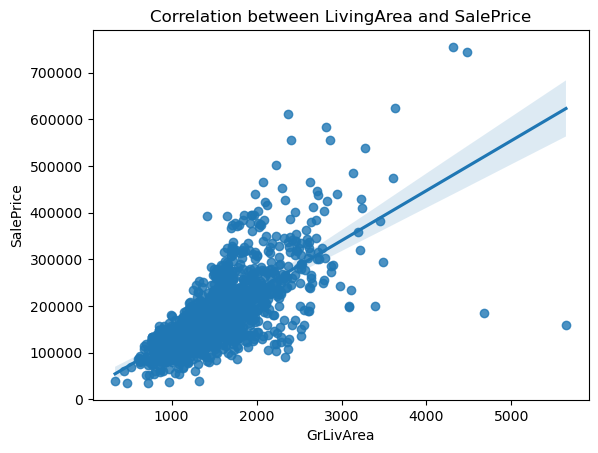

In [89]:
sns.regplot(x="GrLivArea",y="SalePrice",data=data)
plt.title("Correlation between LivingArea and SalePrice")
plt.show()

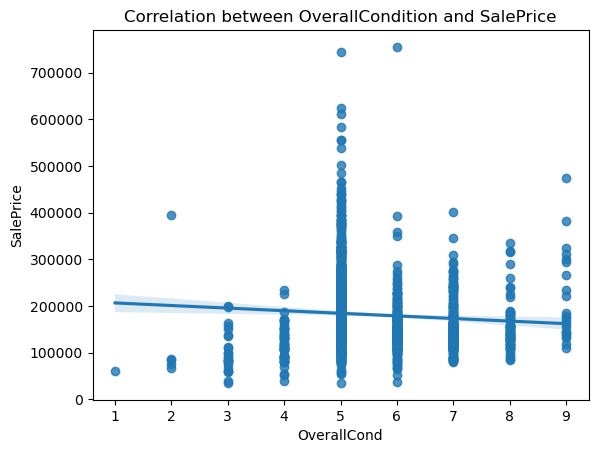

In [90]:
sns.regplot(x="OverallCond",y="SalePrice",data=data)
plt.title("Correlation between OverallCondition and SalePrice")
plt.show()

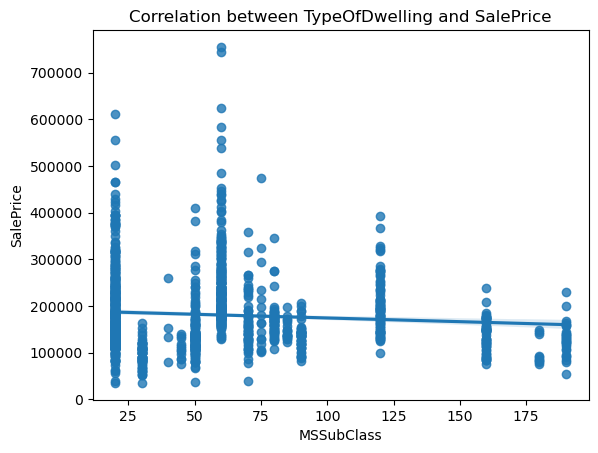

In [91]:
sns.regplot(x="MSSubClass",y="SalePrice",data=data)
plt.title("Correlation between TypeOfDwelling and SalePrice")
plt.show()

In [92]:
for column in categoric_data.columns:
    data[column]=LabelEncoder().fit_transform(data[column])

In [93]:
data.head()

,MSSubClass,MSZoning,LotArea,LotShape,LandContour,Utilities,LotConfig,Neighborhood,OverallQual,OverallCond,...,1stFlrSF,GrLivArea,Functional,GarageType,GarageArea,GarageQual,GarageCond,YrSold,SaleType,SalePrice
0,60,3,8450,3,3,0,4,5,7,5,...,856,1710,6,1,548.0,4,4,2008,8,208500
1,20,3,9600,3,3,0,2,24,6,8,...,1262,1262,6,1,460.0,4,4,2007,8,181500
2,60,3,11250,0,3,0,4,5,7,5,...,920,1786,6,1,608.0,4,4,2008,8,223500
3,70,3,9550,0,3,0,0,6,7,5,...,961,1717,6,5,642.0,4,4,2006,8,140000
4,60,3,14260,0,3,0,2,15,8,5,...,1145,2198,6,1,836.0,4,4,2008,8,250000


In [94]:
df=data[["OverallQual","GrLivArea","1stFlrSF","GarageArea","TotalBsmtSF","Neighborhood","BsmtQual","Foundation","SalePrice"]]
df.head()

,OverallQual,GrLivArea,1stFlrSF,GarageArea,TotalBsmtSF,Neighborhood,BsmtQual,Foundation,SalePrice
0,7,1710,856,548.0,856.0,5,2,2,208500
1,6,1262,1262,460.0,1262.0,24,2,1,181500
2,7,1786,920,608.0,920.0,5,2,2,223500
3,7,1717,961,642.0,756.0,6,3,0,140000
4,8,2198,1145,836.0,1145.0,15,2,2,250000


In [95]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

In [96]:
X.to_numpy
y.to_numpy
X=StandardScaler().fit(X).transform(X.astype(float))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=4)

In [108]:
model=LinearRegression()
model.fit(X_train,y_train)
y_hat=model.predict(X_test)
print("r2_score:",r2_score(y_test,y_hat))
print("mean_squared_error",mean_squared_error(y_test,y_hat)/2)
print("root_mean_squared_error",np.sqrt(mean_squared_error(y_test,y_hat)/2))

r2_score: 0.8495066757686905
mean_squared_error 401980471.5094432
root_mean_squared_error 20049.450653557647


In [109]:
model=Lasso(alpha=3)
model.fit(X_train,y_train)
y_hat=model.predict(X_test)
print("r2_score:",r2_score(y_test,y_hat))
print("mean_squared_error",mean_squared_error(y_test,y_hat)/2)
print("root_mean_squared_error",np.sqrt(mean_squared_error(y_test,y_hat)/2))

r2_score: 0.8495182085686585
mean_squared_error 401949666.4196321
root_mean_squared_error 20048.68241106213


In [99]:
X=data.drop("SalePrice",axis=1)
y=data["SalePrice"]
X.to_numpy
y.to_numpy
X=StandardScaler().fit(X).transform(X.astype(float))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=4)

In [110]:
model=RandomForestRegressor(n_estimators=100,random_state=45)
model.fit(X_train,y_train)
y_hat=model.predict(X_test)
print("r2_score:",r2_score(y_test,y_hat))
print("mean_squared_error",mean_squared_error(y_test,y_hat)/2)
print("root_mean_squared_error",np.sqrt(mean_squared_error(y_test, y_hat)/2))


r2_score: 0.8825311732843943
mean_squared_error 313769229.2464912
root_mean_squared_error 17713.53237630742


In [101]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features=data.columns
for i in indices:
    print(features[i],":",importances[i])

OverallQual : 0.5363842682850061
GrLivArea : 0.1756822826996892
TotalBsmtSF : 0.05868910966006174
1stFlrSF : 0.04264573227017653
GarageArea : 0.037242492611829374
YearBuilt : 0.0303627380675451
LotArea : 0.025207272226589555
Neighborhood : 0.021477871233125036
BsmtQual : 0.017334929763345202
OverallCond : 0.009302888645882072
LotShape : 0.007220909248968778
MSZoning : 0.005838555184539161
Exterior1st : 0.005668668925992995
MSSubClass : 0.0053490937863177705
YrSold : 0.004991227540017688
GarageType : 0.0036504527235969976
LotConfig : 0.003044528255049383
SaleType : 0.0029108679567669544
LandContour : 0.002829349112438959
Foundation : 0.0016748572923085084
Functional : 0.0011770712581655022
BsmtCond : 0.000661463510180033
GarageQual : 0.00047766728460152017
GarageCond : 0.00017441691835753842
Utilities : 1.2855394483787247e-06


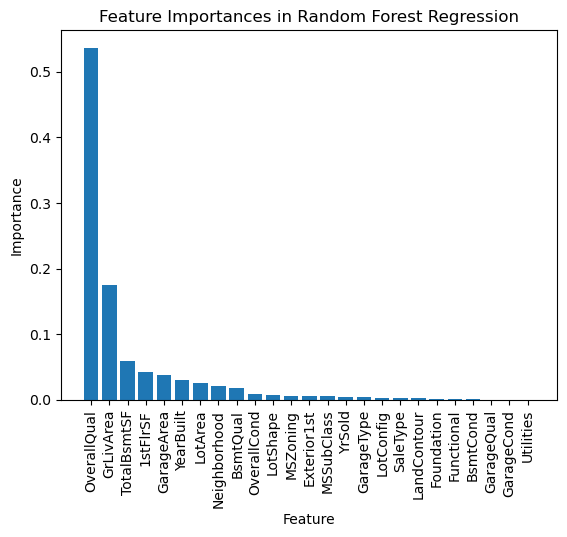

In [103]:
# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

In [111]:
df=data[["OverallQual","GrLivArea","TotalBsmtSF","1stFlrSF","GarageArea","SalePrice"]]
df.head()

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,GarageArea,SalePrice
0,7,1710,856.0,856,548.0,208500
1,6,1262,1262.0,1262,460.0,181500
2,7,1786,920.0,920,608.0,223500
3,7,1717,756.0,961,642.0,140000
4,8,2198,1145.0,1145,836.0,250000


In [112]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]
X.to_numpy
y.to_numpy
X=StandardScaler().fit(X).transform(X.astype(float))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=4)

In [113]:
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_hat=model.predict(X_test)
print("r2_score:",r2_score(y_test,y_hat))
print("mean_squared_error",mean_squared_error(y_test,y_hat)/2)
print("root_mean_squared_error",np.sqrt(mean_squared_error(y_test, y_hat)/2))

r2_score: 0.8474421474922244
mean_squared_error 407495002.1655864
root_mean_squared_error 20186.50544709476
